In [1]:
import pandas as pd

## Reading the data in

In [2]:
music_data = pd.read_csv('music.csv')
music_data

,age,gender,genre
0,20,1,HipHop
1,23,1,HipHop
2,25,1,HipHop
3,26,1,Jazz
4,29,1,Jazz
5,30,1,Jazz
6,31,1,Classical
7,33,1,Classical
8,37,1,Classical
9,20,0,Dance


## Preparing the data

We have to separate data into inputs and outputs

In [3]:
X = music_data.drop(columns='genre')
X

,age,gender
0,20,1
1,23,1
2,25,1
3,26,1
4,29,1
5,30,1
6,31,1
7,33,1
8,37,1
9,20,0


In [4]:
y = music_data['genre']
y

0        HipHop
1        HipHop
2        HipHop
3          Jazz
4          Jazz
5          Jazz
6     Classical
7     Classical
8     Classical
9         Dance
10        Dance
11        Dance
12     Acoustic
13     Acoustic
14     Acoustic
15    Classical
16    Classical
17    Classical
Name: genre, dtype: object

## Classifying the data


In [5]:
from sklearn.tree import DecisionTreeClassifier

In [6]:
model = DecisionTreeClassifier()

## Prediction

Make a prediction based on the entire dataset of which genre a 21 year old male and 22 year old female would prefer

In [7]:
model.fit(X, y)

predictions = model.predict([ [21, 1], [22, 0] ])
predictions

array(['HipHop', 'Dance'], dtype=object)

## Splitting the Data

It is best to have a section of the dataset for training and a section for testing. This will split our current dataset into two.

The test_size argument takes percentage of data for testing. (e.g. 0.2 would mean 20% of the data is used for testing and 80% is used for training)

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

Now that we have the predictions, we need to check the accuracy of the predictions using y_test

In [10]:
from sklearn.metrics import accuracy_score

In [11]:
score = accuracy_score(y_test, predictions)

score

0.5

## Model persistence

It is not ideal to train the model every single time you run. Instead, it is beneficial to train the model and then save that model to be loaded later.

`joblib.dump()` can be used to dump an already trained module into a binary file

In [12]:
import joblib

In [13]:
joblib.dump(model, 'music-recommender.joblib')

['music-recommender.joblib']

After dumping the model, it can then be read in the future

In [14]:
trained_model = joblib.load('music-recommender.joblib')

That model is then ready for predictions

In [15]:
predictions = trained_model.predict([[21, 1]])
predictions

array(['HipHop'], dtype=object)

## Visualizing the learning tree

In [16]:
from sklearn import tree
import matplotlib.pyplot as plt

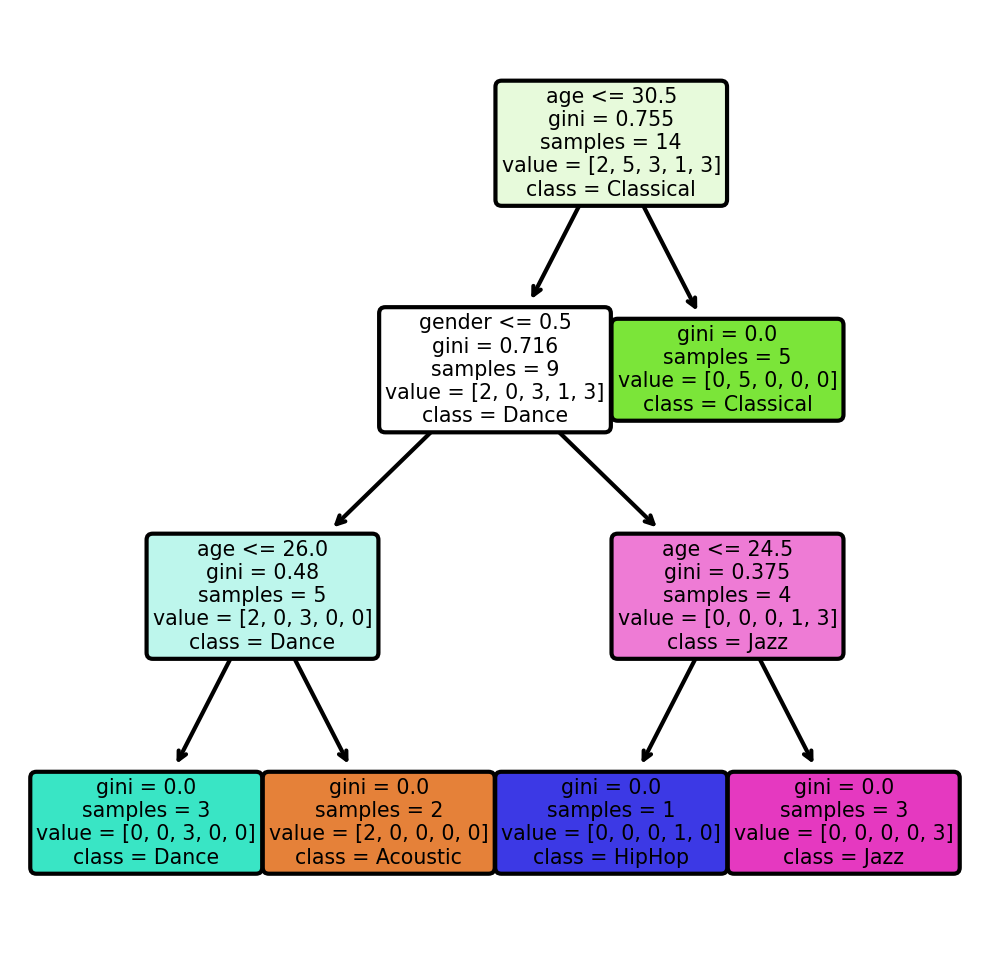

In [17]:
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)

tree.plot_tree(model,
               feature_names = ['age', 'gender'], 
               class_names=sorted(y.unique()),
               label='all',
               rounded=True,
               filled = True)
               
fig.savefig('decision-tree.png')